# Unsupervised Learning - Clustering with K-means + Analyzing WCSS

#### Pedro Mauri Mtz - A01029143

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Data science

In [3]:
df = pd.read_csv(os.path.join(ROOT, "Datasets", "data_unsupervised_learning.csv"))
df_copy = df.copy()

In [4]:
df.shape

(18270, 6)

In [5]:
df.head()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
0,1.884186,80.200851,494.528,NaN,20.915468,161.131180
1,1.889794,79.262886,494.680,NaN,19.383013,160.603470
2,1.896523,74.821999,494.832,NaN,22.591518,160.173615
3,1.891913,72.878922,494.984,NaN,32.191910,160.149429
4,1.880034,71.729141,495.136,NaN,38.495632,160.128342


In [6]:
df.isna().sum()

RHOB           0
GR             0
DEPTH_MD       0
NPHI        4238
PEF         1830
DTC           81
dtype: int64

In [7]:
# Eliminamos las samples con valores Null
df.dropna(inplace = True)
df.isna().sum()

RHOB        0
GR          0
DEPTH_MD    0
NPHI        0
PEF         0
DTC         0
dtype: int64

In [8]:
df.shape

(12202, 6)

### Escalar dataset

In [9]:
scalar = StandardScaler()

In [10]:
df_scaled = df.copy()
df_scaled[["RHOB", "GR", "DEPTH_MD", "NPHI", "PEF", "DTC"]] = scalar.fit_transform(df[["RHOB", "GR", "DEPTH_MD", "NPHI", "PEF", "DTC"]])
df_scaled.head()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
4238,-1.491843,-0.179292,-1.731605,2.523654,-1.255364,0.869531
4239,-1.387067,-0.010859,-1.731322,2.770744,-1.247886,0.690042
4240,-1.320646,0.028875,-1.731038,2.524300,-1.247450,0.554350
4241,-1.274390,-0.008126,-1.730754,2.068584,-1.261572,0.585297
4242,-1.335919,-0.092056,-1.730470,1.617342,-1.325067,0.752808


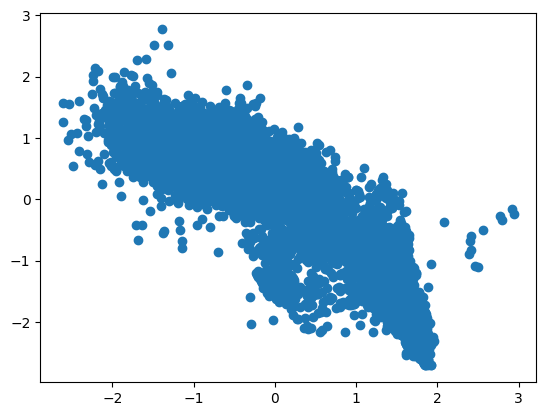

In [11]:
plt.scatter(df_scaled["RHOB"], df_scaled["NPHI"])

### K-means model

In [12]:
km_model = KMeans(n_clusters = 3, random_state = 100)

In [13]:
km_model.fit(df_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,100
,copy_x,True
,algorithm,'lloyd'


In [14]:
km_model.inertia_

28132.706332584094

### Analysing WCSS

In [15]:
WCSS = []

for k in range(1, 10):
    km_model2 = KMeans(n_clusters = k, random_state = 100)
    km_model2.fit(df_scaled)
    print(f"WCSS for k = {k}: {km_model2.inertia_}")
    WCSS.append(km_model2.inertia_)

WCSS for k = 1: 73212.00000000004
WCSS for k = 2: 35006.41646343126
WCSS for k = 3: 28132.706332584094
WCSS for k = 4: 20063.64670599635
WCSS for k = 5: 15913.359090300695
WCSS for k = 6: 14650.076521411742
WCSS for k = 7: 12247.382918042973
WCSS for k = 8: 10748.005086688558
WCSS for k = 9: 9831.367629926184


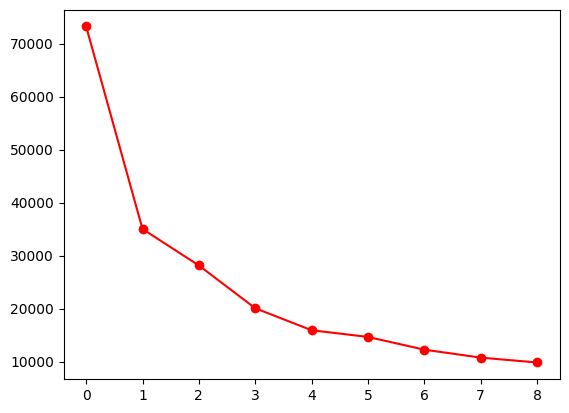

In [16]:
plt.plot(WCSS, marker = "o", color = "red")

In [17]:
km_model3 = KMeans(n_clusters = 2, random_state = 100)
km_model3.fit(df_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,100
,copy_x,True
,algorithm,'lloyd'


In [18]:
df_scaled["Label"] = km_model3.labels_
df_scaled.head()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC,Label
4238,-1.491843,-0.179292,-1.731605,2.523654,-1.255364,0.869531,0
4239,-1.387067,-0.010859,-1.731322,2.770744,-1.247886,0.690042,0
4240,-1.320646,0.028875,-1.731038,2.524300,-1.247450,0.554350,0
4241,-1.274390,-0.008126,-1.730754,2.068584,-1.261572,0.585297,0
4242,-1.335919,-0.092056,-1.730470,1.617342,-1.325067,0.752808,0


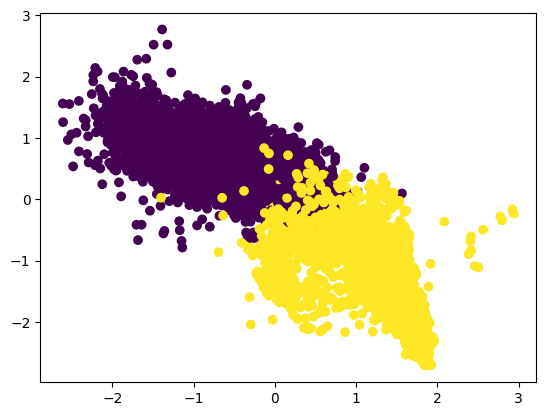

In [19]:
plt.scatter(df_scaled["RHOB"], df_scaled["NPHI"], c=df_scaled["Label"])